In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

## About the synthetic dataset

- URL SOURCE - https://www.kaggle.com/datasets/prasad22/healthcare-dataset/data
- This synthetic healthcare dataset was created to and designed to mimic real-world healthcare data, and was created by Python's Faker library since real healthcare data is difficult to source
- General idea - There is a general need for studying the healthcare analytics domain, and it has a real world impact

### Attributes 
- Each column provides specific information about the patient, their admission, and the healthcare services provided, making this dataset suitable for various data analysis and modeling tasks in the healthcare domain. Here's a brief explanation of each column in the dataset 
- This dataset consists of 10,000 records, each representing a synthetic patient healthcare record.
It includes various attributes, such as patient demographics, medical conditions, admission details, and more.
The dataset is intended for educational and non-commercial use. It is entirely synthetic and does not contain real patient data.

    - **Name**: This column represents the name of the patient associated with the healthcare record.
    - **Age**: The age of the patient at the time of admission, expressed in years.
    - **Gender**: Indicates the gender of the patient, either "Male" or "Female."
    - **Blood Type**: The patient's blood type, which can be one of the common blood types (e.g., "A+", "O-", etc.).
    Medical Condition: This column specifies the primary medical condition or diagnosis associated with the patient, such as "Diabetes," "Hypertension," "Asthma," and more.
    - **Date of Admission**: The date on which the patient was admitted to the healthcare facility.
    - **Doctor**: The name of the doctor responsible for the patient's care during their admission.
    - **Hospital**: Identifies the healthcare facility or hospital where the patient was admitted.
    - **Insurance Provider**: This column indicates the patient's insurance provider, which can be one of several options, including "Aetna," "Blue Cross," "Cigna," "UnitedHealthcare," and "Medicare."
    - **Billing Amount**: The amount of money billed for the patient's healthcare services during their admission. This is expressed as a floating-point number.
    - **Room Number**: The room number where the patient was accommodated during their admission.
    - **Admission Type**: Specifies the type of admission, which can be "Emergency," "Elective," or "Urgent," reflecting the circumstances of the admission.
    - **Discharge Date**: The date on which the patient was discharged from the healthcare facility, based on the admission date and a random number of days within a realistic range.
    - **Medication**: Identifies a medication prescribed or administered to the patient during their admission. Examples include "Aspirin," "Ibuprofen," "Penicillin," "Paracetamol," and "Lipitor."
    - **Test Results**: Describes the results of a medical test conducted during the patient's admission. Possible values include "Normal," "Abnormal," or "Inconclusive," indicating the outcome of the test.


### Exploratory Data Analysis of Healthcare Dataset



From df.head() I noted
- Name casing is not good, i.e. Bobby JacksOn
- Dates need parsng, add datetime and engineer length of stay in future 
- Is **Room Number** numeric or categorical?
- **Doctor**, **Hospital**, **Name** → too many unique values -> df.drop(columns=['Name', 'Doctor', 'Hospital'], inplace=True) later

Basic cleaning will be done in the clean_data.py script

In [13]:
df = pd.read_csv("data/raw/healthcare_dataset.csv")
df.head(5)

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


### Examining the dataset

In [14]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

,Age,Billing Amount,Room Number
count,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829
std,19.602454,14211.454431,115.243069
min,13.000000,-2008.492140,101.000000
25%,35.000000,13241.224652,202.000000
50%,52.000000,25538.069376,302.000000
75%,68.000000,37820.508436,401.000000
max,89.000000,52764.276736,500.000000


#### Missing data analysis


In [15]:
df.isnull().sum().sort_values(ascending=False)

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

### Basic visual exploration 
- On the histogram of the **Age** attribute, I found the following
    - Low youth representation (10-20)
        - Only ~2,500 patients — likely a dataset that excludes pediatric cases or focuses on adult medicine
    - A plateau
        - Counts stay consistently between 5,500–6,800 across most age groups
        - This may suggest the data was sampled or weighted to be more uniform, rather than purely natural
- On the box plot of the **Billing Amount** attribute, I found 
    - Key Statistics (estimated from plot):
        - Median (green line): ~$25,000–26,000
        - Q1 (25th percentile): ~$14,000–15,000
        - Q3 (75th percentile): ~$37,000–38,000
        - IQR: ~$22,000–23,000 — quite wide, indicating high spread
        - Upper whisker: ~$53,000
        - Lower whisker: ~$0 (or slightly negative)
    - Notable observations
        - Negative values exist — a red flag even in synthetic data; billing amounts shouldn't be negative unless representing refunds/adjustments. Worth investigating or clipping
        - No visible outlier dots — the whiskers capture most of the range, meaning the generator didn't produce extreme outliers beyond the expected range
        - Slightly right-skewed — median is closer to Q1 than Q3, meaning more cases cluster at lower billing amounts
        - Wide IQR suggests billing was generated across a very broad uniform-like range, consistent with synthetic data
- Additional look into **Billing Amount** 
    - Mean (~25,539) ≈ Median (~25,538) — almost perfectly symmetric, a hallmark of synthetically generated uniform data
Skewness of -0.001 — essentially zero, confirming near-perfect symmetry
Kurtosis of -1.19 — strongly confirms a uniform distribution (normal would be ~0, uniform is typically around -1.2)

- Spread
    - Std Dev of ~14,211 on a range of ~54,772 is consistent with a uniform distribution (theoretical std dev would be range/√12 ≈ 15,810 — very close)
IQR of ~24,579 is very wide, meaning billing costs are genuinely spread across the full range with no natural clustering

- Negative Values
    - Only 108 out of 55,500 (0.19%) — very small but worth addressing
Likely a generation artifact where the lower bound was set slightly below 0
Recommendation: clip to 0 before modeling

- Outliers
    - Zero outliers by IQR method — makes complete sense since a uniform distribution has no tails, so nothing falls beyond 1.5×IQR
This also means traditional outlier removal won't work here — every value is equally valid by design

- Normality
    - Shapiro p-value of 0.000 — definitively not normal This matters for modeling — algorithms that assume normality (e.g., Linear Regression) may benefit from a transformation:

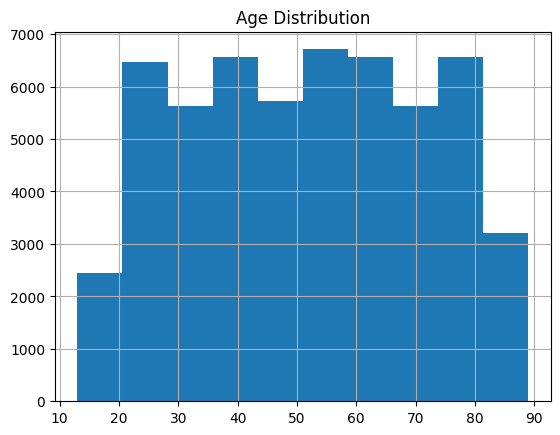

In [16]:
import matplotlib.pyplot as plt

df["Age"].hist()
plt.title("Age Distribution")
plt.show()

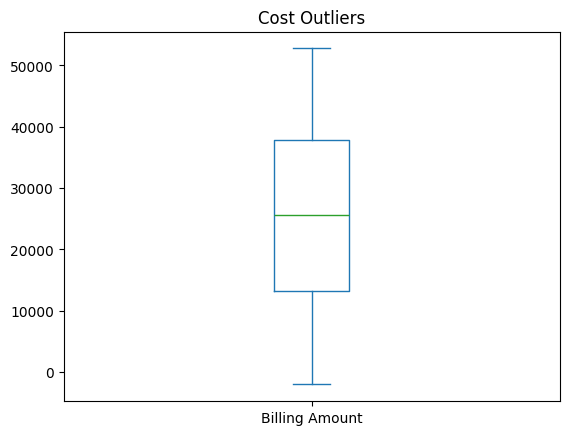

       DESCRIPTIVE STATISTICS
Count:                   55500
Mean:                 25539.32
Median:               25538.07
Std Dev:              14211.45
Variance:           201965437.04
Min:                  -2008.49
Max:                  52764.28
Range:                54772.77
Q1 (25th):            13241.22
Q3 (75th):            37820.51
IQR:                  24579.28
Skewness:              -0.0010
Kurtosis:              -1.1906

Negative values:           108
% Negative:              0.19%

── Outlier Detection (IQR Method) ──
Lower bound:         -23627.70
Upper bound:          74689.43
Outlier count:               0
% Outliers:              0.00%

── Shapiro-Wilk Normality Test ──
Statistic:              0.9602
P-value:                0.0000
Normal?                     No


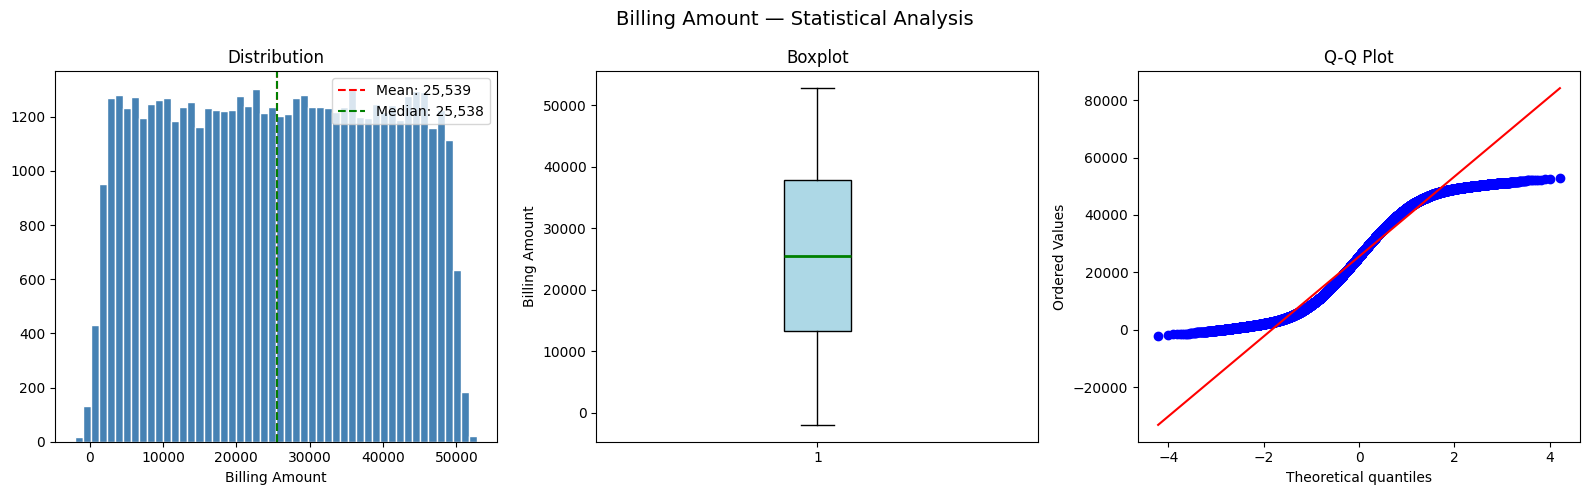

In [ ]:
# Examining the billing amount attribute

df["Billing Amount"].plot(kind="box")
plt.title("Cost Outliers")
plt.show()




col = df['Billing Amount']

# ── 1. Descriptive Statistics ──────────────────────────────
print("=" * 45)
print("       DESCRIPTIVE STATISTICS")
print("=" * 45)
print(f"Count:              {col.count():>10}")
print(f"Mean:               {col.mean():>10.2f}")
print(f"Median:             {col.median():>10.2f}")
print(f"Std Dev:            {col.std():>10.2f}")
print(f"Variance:           {col.var():>10.2f}")
print(f"Min:                {col.min():>10.2f}")
print(f"Max:                {col.max():>10.2f}")
print(f"Range:              {col.max() - col.min():>10.2f}")
print(f"Q1 (25th):          {col.quantile(0.25):>10.2f}")
print(f"Q3 (75th):          {col.quantile(0.75):>10.2f}")
print(f"IQR:                {col.quantile(0.75) - col.quantile(0.25):>10.2f}")
print(f"Skewness:           {col.skew():>10.4f}")
print(f"Kurtosis:           {col.kurt():>10.4f}")

# ── 2. Negative Value Check ────────────────────────────────
negatives = col[col < 0]
print(f"\nNegative values:    {len(negatives):>10}")
print(f"% Negative:         {(len(negatives)/len(col)*100):>9.2f}%")

# ── 3. Outlier Detection (IQR method) ─────────────────────
Q1 = col.quantile(0.25)
Q3 = col.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = col[(col < lower_bound) | (col > upper_bound)]
print(f"\n── Outlier Detection (IQR Method) ──")
print(f"Lower bound:        {lower_bound:>10.2f}")
print(f"Upper bound:        {upper_bound:>10.2f}")
print(f"Outlier count:      {len(outliers):>10}")
print(f"% Outliers:         {(len(outliers)/len(col)*100):>9.2f}%")

# ── 4. Normality Test ──────────────────────────────────────
stat, p_value = stats.shapiro(col.sample(min(5000, len(col)), random_state=42))
print(f"\n── Shapiro-Wilk Normality Test ──")
print(f"Statistic:          {stat:>10.4f}")
print(f"P-value:            {p_value:>10.4f}")
print(f"Normal?             {'Yes' if p_value > 0.05 else 'No':>10}")

# ── 5. Visualizations ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Billing Amount — Statistical Analysis", fontsize=14)

# Histogram
axes[0].hist(col, bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(col.mean(), color='red', linestyle='--', label=f'Mean: {col.mean():,.0f}')
axes[0].axvline(col.median(), color='green', linestyle='--', label=f'Median: {col.median():,.0f}')
axes[0].set_title("Distribution")
axes[0].set_xlabel("Billing Amount")
axes[0].legend()

# Boxplot
axes[1].boxplot(col, patch_artist=True,
                boxprops=dict(facecolor='lightblue'),
                medianprops=dict(color='green', linewidth=2))
axes[1].set_title("Boxplot")
axes[1].set_ylabel("Billing Amount")

# QQ Plot (normality check)
stats.probplot(col, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q Plot")

plt.tight_layout()
plt.show()